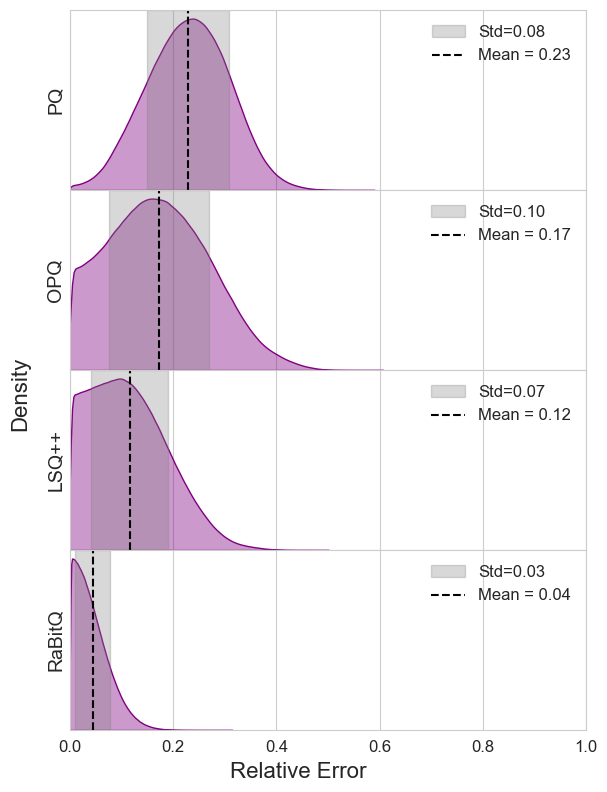

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path to results directory
base_dir = "/data/cpanourg/2-hdvc/results"

# Define methods and their rel_error.bin paths
methods = {
    "PQ": os.path.join(base_dir, "pq", "rel_error.bin"),
    "OPQ": os.path.join(base_dir, "opq", "rel_error.bin"),
    "LSQ++": os.path.join(base_dir, "lsq_pp", "rel_error.bin"),
    "RaBitQ": os.path.join(base_dir, "rabitq", "rel_error.bin")
}

# Styling
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})
sns.set_style("whitegrid")

# Create vertically stacked plots (shared X-axis)
fig, axes = plt.subplots(len(methods), 1, figsize=(6, 8), sharex=True)

for ax, (method_name, path) in zip(axes, methods.items()):
    # Load data
    rel_error = np.fromfile(path, dtype=np.float32)
    rel_error = rel_error[np.isfinite(rel_error)]

    mean_rel, std_rel = rel_error.mean(), rel_error.std()

    # KDE plot
    sns.kdeplot(rel_error, fill=True, color="purple", alpha=0.4, ax=ax)

    # ±1 std region and mean line
    ax.axvspan(mean_rel - std_rel, mean_rel + std_rel, color="grey", alpha=0.3, label=f"Std={std_rel:.2f}")
    ax.axvline(mean_rel, linestyle="--", color="black", label=f"Mean = {mean_rel:.2f}")

    # Limits, labels, and legend
    ax.set_xlim(0, 1)
    ax.set_ylabel(f"{method_name}")
    ax.legend(frameon=False, loc="upper right")
    ax.set_yticks([])

# Common axis labels
fig.text(0.5, 0.02, "Relative Error", ha="center", fontsize=16)
fig.text(0.02, 0.5, "Density", va="center", rotation="vertical", fontsize=16)

# ⬇️ Remove all vertical space between plots
plt.subplots_adjust(hspace=0, left=0.12, right=0.98, bottom=0.08, top=0.98)

plt.show()
